# rs-embed Playground
<img src="https://raw.githubusercontent.com/cybergis/rs-embed/main/docs/assets/background.png" width="800" /> 

The remote sensing community is witnessing a rapid growth of foundation models, which provide powerful embeddings for a wide range of downstream tasks. However, practical adoption and fair comparison remain challenging due to substantial heterogeneity in model release formats, platforms and interfaces, and input data specifications. These inconsistencies significantly increase the cost of obtaining, using, and benchmarking embeddings across models. To address this issue, we propose rs-embed, a Python library that offers a unified, region of interst (ROI) centric interface: with a single line of code, users can retrieve embeddings from any supported model for any location and any time range. The library also provides efficient batch processing to enable large-scale embedding generation and evaluation. 

This notebook demonstrates **direct usage** from `rs_embed`.



The goal is to clearly expose the **core toolkit API**:
- spatial inputs (`PointBuffer`, `BBox`)
- temporal specs (`year`, `range`)
- output specs (`pooled`, `grid`)
- returned `data` and `meta`

> Select Kernel: `rsembed`



In [ ]:
!git clone https://github.com/cybergis/rs-embed.git
%cd rs-embed
%pip install -e .

In [1]:
from rs_embed import BBox, PointBuffer, TemporalSpec, OutputSpec,SensorSpec
from rs_embed import inspect_gee_patch, get_embedding, get_embeddings_batch, export_batch
from plot_utils import *

import json

## 1. Define spatial and temporal inputs

In [2]:
# Spatial: point + buffer
spatial_point = PointBuffer(
    lon=121.5, #, -122.407677
    lat=31.2, # 37.787937
    buffer_m=2048,
)

# Spatial: bounding box
spatial_bbox = BBox(
    minlon=121.45,
    minlat=31.15,
    maxlon=121.65,
    maxlat=31.25,
)

# Temporal: single year
temporal_year = TemporalSpec.year(2024)

# Temporal: date range
temporal_range = TemporalSpec.range(
    "2022-06-01",
    "2022-09-01",

)

spatial_point, spatial_bbox, temporal_year, temporal_range

(PointBuffer(lon=121.5, lat=31.2, buffer_m=2048, crs='EPSG:4326'),
 BBox(minlon=121.45, minlat=31.15, maxlon=121.65, maxlat=31.25, crs='EPSG:4326'),
 TemporalSpec(mode='year', year=2024, start=None, end=None),
 TemporalSpec(mode='range', year=<function TemporalSpec.year at 0x14f419c79580>, start='2022-06-01', end='2022-09-01'))

check the area

ok: True


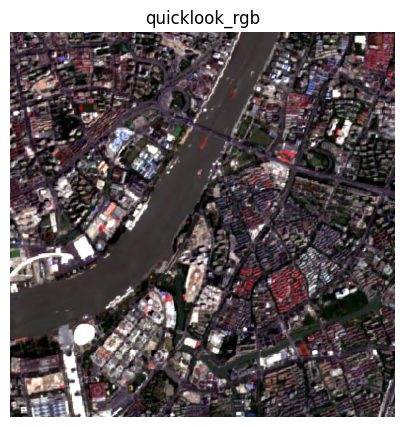

In [15]:

check_out = inspect_gee_patch(
    spatial=spatial_point,
    temporal=temporal_range,
    sensor=SensorSpec(
        collection="COPERNICUS/S2_SR_HARMONIZED",
        bands=("B4", "B3", "B2"),
        scale_m=10,
        cloudy_pct=10,
        composite="median",
        fill_value=0.0,
        check_save_dir="./_gee_checks",
    ),
    value_range=(0, 10000),
)

print("ok:", check_out.get("ok"))
show_quicklook_artifact(check_out.get("artifacts") or {})


ok: False
bands: ('VV', 'VH')
S1 CHW: (2, 410, 410) float32 min= -26.330251693725586 max= 33.094207763671875


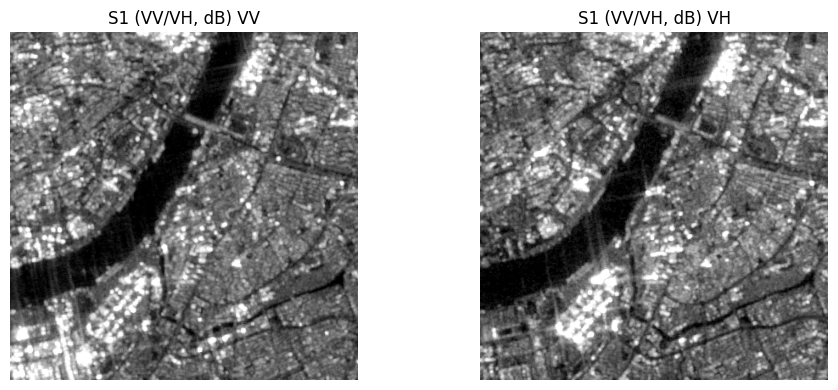

In [4]:
# Sentinel-1 (VV/VH) inspection for the same region/time window
s1_check_out = inspect_gee_patch(
    spatial=spatial_point,
    temporal=temporal_range,
    sensor=SensorSpec(
        collection="COPERNICUS/S1_GRD",  # dB-scale backscatter
        bands=("VV", "VH"),
        scale_m=10,
        cloudy_pct=None,
        composite="median",
        fill_value=-35.0,
        check_save_dir="./_gee_checks",
    ),
    name="s1_vvvh_patch",
    value_range=(-50, 10),
    return_array=True,
)

show_s1_vvvh_from_inspect(s1_check_out, title_prefix="S1 (VV/VH, dB)",flipud=True)


## 2. Precomputed embedding example

- Spatial: `BBox`
- Temporal: `year`
- Output: `grid`


### 2.1 GSE_annual(Alpha Earth)


data.shape: (64, 410, 410)


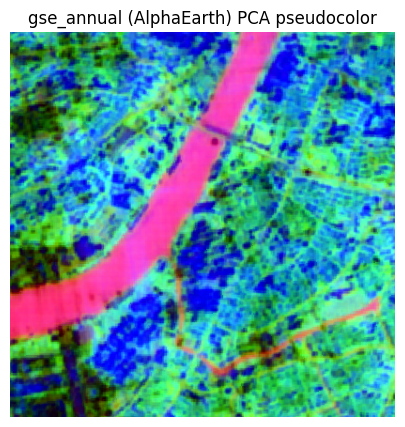

{'mean': array([ 0.07853824, -0.29107493,  0.1161385 , -0.01957924,  0.02499747,
        -0.07961908, -0.09171757, -0.04517604, -0.16079898,  0.08444491,
         0.04607062,  0.04059851, -0.15324387, -0.15063843, -0.11724014,
        -0.11368866,  0.08037771,  0.14151959, -0.07956102,  0.07384185,
        -0.04462529,  0.10088068, -0.10032278,  0.01416243, -0.05940819,
         0.23154068,  0.00040225, -0.0277066 ,  0.15224236,  0.0368964 ,
         0.0367008 ,  0.01560507, -0.07904538, -0.04380777,  0.11977525,
        -0.0081563 , -0.20165128, -0.06312177,  0.05876789,  0.02970741,
        -0.07101694, -0.02973392, -0.0059794 ,  0.04876955,  0.10008385,
         0.16855767, -0.06602319,  0.15204938,  0.12364287,  0.04426003,
        -0.08971214,  0.09532284, -0.1818591 ,  0.07876746,  0.19386826,
        -0.28169596,  0.03485641,  0.04957942,  0.03513833,  0.01825983,
        -0.02705266, -0.13622743, -0.08715788,  0.07614619], dtype=float32),
 'components': array([[-1.00033954e-01,

<Figure size 640x480 with 0 Axes>

In [5]:
emb = get_embedding(
    "gse_annual",
    spatial=spatial_point,
    temporal=temporal_year,
    output=OutputSpec.grid(),
)

print("data.shape:", emb.data.shape)
# print("source:", emb.meta.get("source"))

plot_embedding_pseudocolor(
    emb,
    title="gse_annual (AlphaEarth) PCA pseudocolor",
)

### 2.2 Tessera

data.shape: (128, 403, 416)


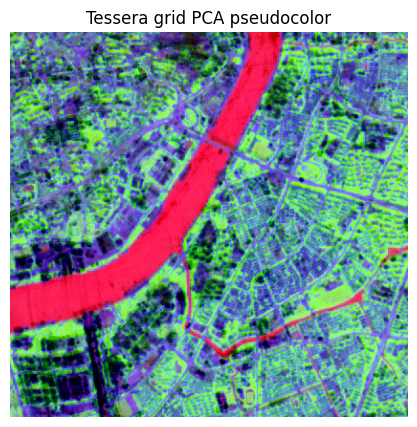

{'mean': array([ 3.1960571e+00, -2.8661504e+00, -1.2045557e+00,  4.0560160e+00,
        -1.0441488e+00, -1.5309714e+00, -1.6139755e+00, -1.2970990e+00,
        -4.0516379e-01,  1.8469477e+00, -1.2965550e-01,  3.1828473e+00,
         1.2677317e+00, -2.9585576e+00, -1.8621333e+00,  8.5151500e-01,
        -2.6369163e-01,  2.3083189e+00, -2.2967416e-01,  1.4172567e+00,
         3.0589025e+00,  1.9628842e+00,  2.0570407e+00, -1.6302434e+00,
         5.0134268e+00,  9.2652595e-01, -1.6763446e+00,  2.7555006e+00,
        -1.8487889e+00,  3.4271851e+00, -2.0356665e+00,  2.9067388e+00,
        -2.1346905e+00,  8.8696557e-01,  1.7524476e+00, -5.5445927e-01,
         3.6104107e+00,  5.1247752e-01,  5.8176544e-02, -1.0170799e+00,
         1.5882216e-01, -2.2565756e+00,  1.8190869e+00,  2.6467519e+00,
         4.8037684e-01,  3.4319597e-01,  1.2925552e-01, -1.6814635e+00,
         2.6798224e+00, -4.1041799e+00, -2.8956103e+00, -9.6349084e-01,
        -2.5181255e+00, -3.0912554e+00,  3.2475519e+00, 

<Figure size 640x480 with 0 Axes>

In [6]:
emb_tessera_grid = get_embedding(
    "tessera",
    spatial=spatial_point,
    temporal=temporal_year,
    output=OutputSpec.grid()
)

print("data.shape:", emb_tessera_grid.data.shape)
# print("meta keys:", list(emb_tessera_grid.meta.keys()))

plot_embedding_pseudocolor(
    emb_tessera_grid,
    title="Tessera grid PCA pseudocolor",
)

## 3. On-the-fly model: `remoteclip`

### 3.1 Pooled output
- Spatial: `PointBuffer`
- Temporal: date range
- Output: `pooled(mean)`


In [8]:
emb_remoteclip_pooled = get_embedding(
    "remoteclip",
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.pooled(),
    backend='gee'
)

print("data.shape:", emb_remoteclip_pooled.data.shape)
print("model:", emb_remoteclip_pooled.meta.get("model"))

print(json.dumps(emb_remoteclip_pooled.meta, indent=2)[:100])

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights from local directory
data.shape: (768,)
model: remoteclip
{
  "model": "remoteclip",
  "type": "on_the_fly",
  "backend": "gee",
  "source": "COPERNICUS/S2_SR


### 3.2 Grid output

Tips: If you want to obtain a higher resolution of the embed, please use the        `input_prep='resize'` or `InputPrepSpec` to specify the input image preprocessing method. The rs-embed module by default resizes to the input size of the corresponding model. However, it also supports "tiles", where the input image is first divided and then concatenated at the embedding level.

More info: https://cybergis.github.io/rs-embed/api_specs/#inputprepspec

/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param ground_covers for model encoder with [2880]
  return self._registry[name](*constructor_args, **construc

data.shape: (768, 18, 18)
grid_hw: None


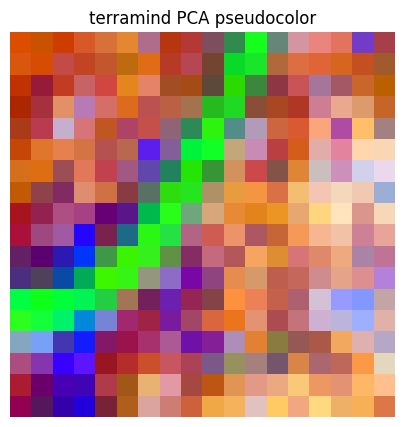

{'mean': array([ 2.66241384e+00, -1.62707388e+00,  4.14298445e-01, -4.01454866e-01,
        -5.31336069e-02, -2.08423898e-01,  5.30888498e-01, -1.80731070e+00,
        -8.27298641e-01,  8.81875396e-01, -8.77899051e-01, -1.01018393e+00,
         8.90711546e-01,  1.16121960e+00, -1.52166173e-01, -3.33094597e-01,
        -1.34987497e+00,  3.45589638e+00, -3.64407212e-01,  1.66632140e+00,
         4.10852551e-01, -1.43087840e+00,  1.93233252e+00,  5.23853838e-01,
         4.76020098e-01,  2.21907139e+00,  2.53701377e+00,  9.23871100e-01,
         7.86805689e-01,  9.27513599e-01,  5.81941128e-01, -7.51982629e-01,
        -1.47458029e+00, -1.88479388e+00,  4.36917877e+00,  4.90204096e-01,
        -1.18239319e+00, -1.15698826e+00,  3.85660857e-01,  1.97299588e+00,
        -1.40627623e+00, -3.16019058e-02,  4.18821669e+00,  4.41866130e-01,
         1.80328444e-01,  1.62891185e+00,  6.77517593e-01,  7.06678987e-01,
         6.06209397e-01, -1.11822963e+00,  1.18390751e+00, -2.12077904e+00,
    

<Figure size 640x480 with 0 Axes>

In [ ]:
from rs_embed import InputPrepSpec
emb_remoteclip_grid = get_embedding(
    "terramind",#"", #terramind
    spatial=spatial_point,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    input_prep = InputPrepSpec( # or you can simply 'tile'/'resize'
        mode="resize",
        max_tiles = 60,
        pad_edges = False
    ),
    backend='gee'
)

print("data.shape:", emb_remoteclip_grid.data.shape)
print("grid_hw:", emb_remoteclip_grid.meta.get("grid_hw"))

plot_embedding_pseudocolor(
    emb_remoteclip_grid,
    title="terramind PCA pseudocolor",
    flipud=True
)

## 4. Get Embedding Batches

In [ ]:
from rs_embed import get_embeddings_batch

points = [
    PointBuffer(lon=121.5, lat=31.2, buffer_m=100),
    PointBuffer(lon=121.6, lat=31.3, buffer_m=100),
    PointBuffer(lon=120.0, lat=30.0, buffer_m=100),
]

embeddings = get_embeddings_batch(
    "satmae",
    spatials=points,
    temporal=temporal_range,
    output=OutputSpec.grid(),
    backend="gee"
)

for i, emb in enumerate(embeddings):
    print(f"Embedding {i} shape: {emb.data.shape}")


/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Embedding 0 shape: (1024, 14, 14)
Embedding 1 shape: (1024, 14, 14)
Embedding 2 shape: (1024, 14, 14)


## 5. `export_batch()`
>  This API is designed for **rapid batch processing**. 
- Minimal example: export multi-point inputs + embeddings + manifest.
- Then inspect one file with a single helper call.

More info: https://cybergis.github.io/rs-embed/api_export/

In [12]:
export_batch(
    out_dir="exports",
    names=["p1", "p2"],
    spatials=[
        PointBuffer(lon=121.5, lat=31.2, buffer_m=200),
        PointBuffer(lon=120.5, lat=30.2, buffer_m=200),
    ],
    temporal=temporal_range,
    models=["remoteclip", "prithvi"],
    output=OutputSpec.pooled(),
    save_inputs=True,
    backend="gee"
)


/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


export_batch:   0%|          | 0/2 [00:00<?, ?point/s]

infer[remoteclip]:   0%|          | 0/2 [00:00<?, ?point/s]

infer[prithvi]:   0%|          | 0/2 [00:00<?, ?point/s]

/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights from local directory


/u/dingqi2/miniconda3/envs/torchgeo/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


[{'created_at': '2026-03-08T01:21:48+00:00Z',
  'point_index': 0,
  'status': 'ok',
  'backend': 'gee',
  'device': 'auto',
  'models': [{'model': 'remoteclip',
    'status': 'ok',
    'sensor': {'collection': 'COPERNICUS/S2_SR_HARMONIZED',
     'bands': ['B4', 'B3', 'B2'],
     'scale_m': 10,
     'cloudy_pct': 30,
     'fill_value': 0.0,
     'composite': 'median',
     'check_input': False,
     'check_raise': True,
     'check_save_dir': None},
    'describe': {'type': 'on_the_fly',
     'backend': ['provider'],
     'inputs': {'collection': 'COPERNICUS/S2_SR_HARMONIZED',
      'bands': ['B4', 'B3', 'B2']},
     'temporal': {'mode': 'range'},
     'output': ['pooled', 'grid'],
     'defaults': {'scale_m': 10,
      'cloudy_pct': 30,
      'composite': 'median',
      'ckpt': 'MVRL/remote-clip-vit-base-patch32',
      'image_size': 224},
     'notes': 'grid output is ViT token grid (patch-level), typically 7x7 for ViT-B/32 at 224px.'},
    'input': {'npz_key': 'input_chw__remoteclip

Inspect one exported file (read + summary + exact input visualization)


=== Manifest summary ===
npz_path: None
backend: gee
spatial: {'lon': 121.5, 'lat': 31.2, 'buffer_m': 200, 'crs': 'EPSG:4326'}
temporal: {'mode': 'range', 'year': '<function TemporalSpec.year at 0x14f419c79580>', 'start': '2022-06-01', 'end': '2022-09-01'}
npz_keys: ['input_chw__remoteclip', 'embedding__remoteclip', 'input_chw__prithvi', 'embedding__prithvi']

=== model -> input key ===
remoteclip: input_chw__remoteclip
prithvi: input_chw__prithvi

=== Visualizing exact model inputs ===
input_chw__remoteclip <- remoteclip      shape=(3, 41, 41) dtype=float32 min=0 max=3.35e+03


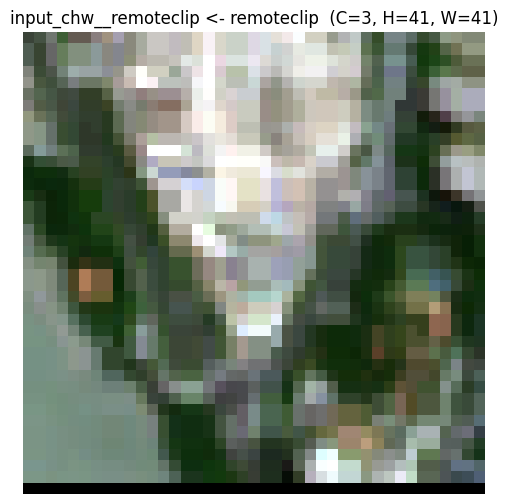

input_chw__prithvi <- prithvi            shape=(6, 15, 14) dtype=float32 min=0 max=4.57e+03


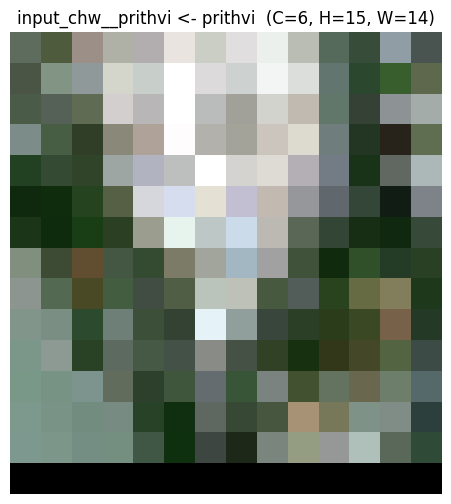

In [13]:
manifest, z = inspect_export_npz("exports/p1.npz")